# 📏 Exercício: Intervalos de Predição Conforme com Variância Heterocedástica

Neste exercício, você irá aplicar **Conformal Prediction** em um conjunto de dados sintético onde a variância dos erros depende da entrada. Seu objetivo será prever não apenas o valor de saída, mas também construir **intervalos de predição válidos**, mesmo quando a incerteza varia com $x$.

---

## 📂 Passo 1 — Gerando os dados

Execute o código abaixo para criar um conjunto de dados com ruído que cresce com $|x|$:

    import numpy as np
    import pandas as pd

    def make_variable_data(n, std_dev=1/5):
        x = np.random.uniform(low=-1, high=1, size=n)
        y = (x**3) + 2 * np.exp(-6 * (x - 0.3)**2)
        y += np.random.normal(scale=std_dev * np.abs(x), size=n)
        df = pd.DataFrame({'x': x, 'y': y})
        return df

    # Gerando os dados
    df = make_variable_data(300)
    print(df.head())

---

## 🔍 Tarefa

Aplique **Split Conformal Prediction** usando um modelo de regressão de sua escolha (ex: Boosting). Divida os dados em três conjuntos:

- Treino
- Calibração
- Teste

Construa intervalos de predição com nível de confiança $1 - \alpha = 90\%$, e **visualize os intervalos junto com os pontos reais**.

---


<Axes: xlabel='x', ylabel='y'>

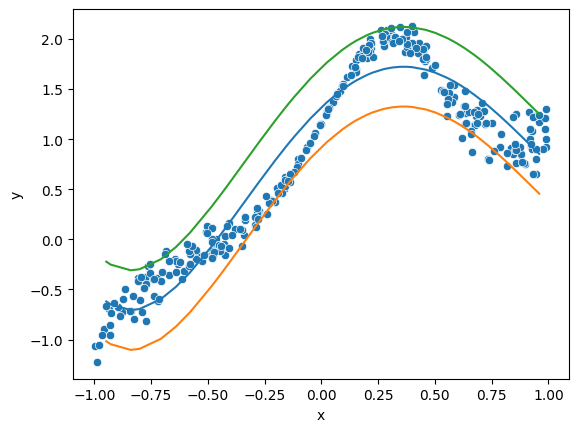

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

from sklearn.pipeline import make_pipeline

# Load Data
def make_variable_data(n, std_dev=1/5):
    x = np.random.uniform(low=-1, high=1, size=n)
    y = (x**3) + 2 * np.exp(-6 * (x - 0.3)**2)
    y += np.random.normal(scale=std_dev * np.abs(x), size=n)
    df = pd.DataFrame({'x': x, 'y': y})
    return df


df = make_variable_data(300)

X=df[['x']]
y=df['y']
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=42)

# Build Model
model = make_pipeline(PolynomialFeatures(degree=4), LinearRegression())
model.fit(X_train, y_train)

y_calib_pred = model.predict(X_calib)
residuals = np.abs(y_calib - y_calib_pred)
alpha = 0.1
n_calib = len(residuals)
q = np.quantile(residuals, np.ceil((1 - alpha) * (n_calib + 1)) / n_calib)

df_test = X_test.copy()
df_test['target'] = y_test
df_test['prediction'] = model.predict(X_test)
df_test['lower'] = df_test['prediction'] - q
df_test['upper'] = df_test['prediction'] + q

sns.scatterplot(data=df, x='x', y='y')
sns.lineplot(data=df_test, x='x', y='prediction')
sns.lineplot(data=df_test, x='x', y='lower')
sns.lineplot(data=df_test, x='x', y='upper')

# 📏 Exercício: Conformal Prediction com Boosting e Partições Locais

Neste exercício, você aplicará **Predição Conforme para regressão**, utilizando **Boosting** como modelo base. A inovação será construir **intervalos adaptativos**, baseando-se em uma **árvore de decisão treinada sobre os resíduos** para identificar regiões com diferentes níveis de incerteza.

---

## 📂 Passo 1 — Geração dos dados

Use o código abaixo para gerar dados sintéticos com variância que depende da entrada:

    import numpy as np
    import pandas as pd

    def make_variable_data(n, std_dev=1/5):
        x = np.random.uniform(low=-1, high=1, size=n)
        y = (x**3) + 2 * np.exp(-6 * (x - 0.3)**2)
        y += np.random.normal(scale=std_dev * np.abs(x), size=n)
        df = pd.DataFrame({'x': x, 'y': y})
        return df

    df = make_variable_data(300)

---

## 📋 Instruções

1. **Divida os dados** em três conjuntos: treino, calibração e teste.  
   Em seguida, divida o conjunto de calibração em duas partes de igual tamanho.

2. **Treine um modelo de boosting** (por exemplo, GradientBoostingRegressor) usando apenas o conjunto de treino.

3. **Use a primeira metade da calibração** para calcular os resíduos absolutos do modelo e treine uma **árvore de decisão** para aprender a estrutura desses resíduos.

4. **Aplique a árvore na segunda metade da calibração**, e para cada folha, calcule o **quantil ajustado** dos resíduos dessa região.

5. **No conjunto de teste**, para cada ponto:
   - Identifique a folha correspondente da árvore.
   - Use o quantil da folha para construir um **intervalo de predição adaptado**.

6. **Visualize os resultados**:
   - Plote as predições do modelo como linha.
   - Mostre os intervalos como faixas adaptadas por região.
   - Sobreponha os pontos reais para avaliar a cobertura.
   - Compare com o método de predição conforme usual.

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
import collections

def make_variable_data(n, std_dev=1/5):
    x = np.random.uniform(low=-1, high=1, size=n)
    y = (x**3) + 2 * np.exp(-6 * (x - 0.3)**2)
    y += np.random.normal(scale=std_dev * np.abs(x), size=n)
    df = pd.DataFrame({'x': x, 'y': y})
    return df

df = make_variable_data(300)

In [3]:
df = make_variable_data(300)

df_train, df_rest = train_test_split(df, test_size=0.4, random_state=42)
df_calib, df_test = train_test_split(df_rest, test_size=0.5, random_state=42)

df_calib_1, df_calib_2 = np.array_split(df_calib, 2)

/Users/vho/dev/mestrado/curso_aprendizado/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [4]:
X_train = df_train[['x']].values
y_train = df_train['y'].values

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [5]:
X_calib_1 = df_calib_1[['x']].values
y_calib_1 = df_calib_1['y'].values
residuals_1 = np.abs(y_calib_1 - model.predict(X_calib_1))

tree = DecisionTreeRegressor(max_leaf_nodes=20, random_state=42)
tree.fit(X_calib_1, residuals_1)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,20
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [6]:
X_calib_2 = df_calib_2[['x']].values
y_calib_2 = df_calib_2['y'].values


preds_calib_2 = model.predict(X_calib_2)
residuals_calib_2 = np.abs(y_calib_2 - preds_calib_2)

leaf_indices = tree.apply(X_calib_2)


folha_residuals = collections.defaultdict(list)
for idx, leaf in enumerate(leaf_indices):
    folha_residuals[leaf].append(residuals_calib_2[idx])


quantile_level = 0.9
folha_quantiles = {}
for leaf, res_list in folha_residuals.items():
    folha_quantiles[leaf] = np.quantile(res_list, quantile_level)


In [7]:
X_test = df_test[['x']].values
y_test = df_test['y'].values

leafs_test = tree.apply(X_test)
intervals = []

for i, x_val in enumerate(X_test):
    leaf = leafs_test[i]
    q = folha_quantiles.get(leaf, np.mean(list(folha_quantiles.values())))
    pred = model.predict(x_val.reshape(1, -1))[0]
    lower = pred - q
    upper = pred + q
    intervals.append((lower, upper))


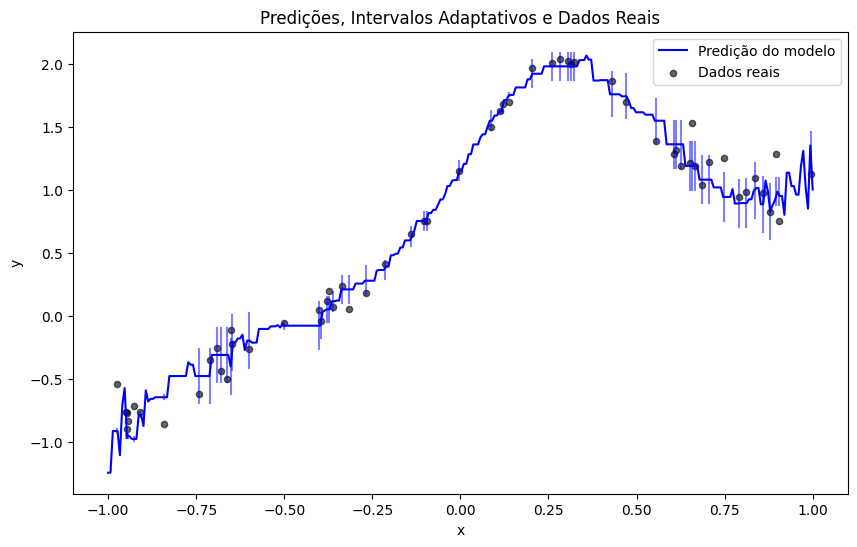

In [10]:
X_plot = np.linspace(-1, 1, 300).reshape(-1,1)
y_pred = model.predict(X_plot)

plt.figure(figsize=(10,6))
plt.plot(X_plot, y_pred, label='Predição do modelo', color='blue')

for i in range(len(X_test)):
    plt.plot([X_test[i], X_test[i]], [intervals[i][0], intervals[i][1]], color='blue', alpha=0.5)

plt.scatter(df_test['x'], df_test['y'], color='black', s=20, alpha=0.6, label='Dados reais')

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predições, Intervalos Adaptativos e Dados Reais')
plt.show()
